<a href="https://colab.research.google.com/github/NguyenThai365/pka-google-colab-notebook/blob/main/%5BOR_AI%5D%2023010531_Tutorial_RL2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Thực hành Reinforcement Learning: Taxi-v4 và Blackjack-v1

**Mục tiêu học tập**

- Ôn lại vòng lặp tương tác cơ bản trong Reinforcement Learning: `state → action → reward → next_state`.
- Hiểu vì sao `Taxi-v4` và `Blackjack-v1` phù hợp với **tabular Q-learning**.
- Cài đặt Q-learning cho hai dạng trạng thái khác nhau:
  - `Taxi-v4`: trạng thái rời rạc dạng số nguyên.
  - `Blackjack-v1`: trạng thái rời rạc dạng bộ ba `(player_sum, dealer_card, usable_ace)`.
- Đánh giá policy sau huấn luyện bằng nhiều episode.
- Ghi và xem **video một episode sau training** bằng `RecordVideo`.



In [1]:
# Nếu chạy trên Google Colab, có thể cần cài đặt trước.
# Gói toy-text giúp render một số môi trường văn bản thành ảnh RGB để ghi video.
# MoviePy / imageio-ffmpeg thường cần cho việc xuất file .mp4.

!pip -q install "gymnasium[toy-text]" moviepy imageio imageio-ffmpeg


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 30.5 MB/s eta 0:00:00


## 1. Import thư viện và các hàm tiện ích

Ta sử dụng:

- `gymnasium`: tạo môi trường RL.
- `numpy`: xử lý Q-table và tính toán số học.
- `matplotlib`: vẽ đường học.
- `RecordVideo`: ghi lại một episode thành video `.mp4`.
- `IPython.display.Video`: hiển thị video ngay trong notebook.


In [2]:
import os
import glob
import shutil
from collections import defaultdict

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import Video, display

try:
    from gymnasium.wrappers import RecordVideo
except Exception:
    # Fallback cho một số phiên bản Gymnasium cũ hơn.
    from gymnasium.wrappers.record_video import RecordVideo


def moving_average(values, window=100):
    """
    Tính trung bình trượt để làm mượt đường reward.
    """
    values = np.asarray(values, dtype=float)
    if len(values) < window:
        return values
    kernel = np.ones(window) / window
    return np.convolve(values, kernel, mode="valid")


def greedy_action(Q, state):
    """
    Chọn action có Q-value lớn nhất.

    Hàm này dùng được cho cả:
    - Q là numpy array: Q[state]
    - Q là defaultdict: Q[state]
    """
    return int(np.argmax(Q[state]))


def epsilon_greedy_action(Q, state, n_actions, epsilon, rng):
    """
    Chính sách epsilon-greedy.

    Với xác suất epsilon: chọn action ngẫu nhiên để khám phá.
    Với xác suất 1 - epsilon: chọn action tốt nhất theo Q hiện tại.
    """
    if rng.random() < epsilon:
        return int(rng.integers(n_actions))
    return greedy_action(Q, state)


def plot_training_curve(rewards, title, window=1000):
    """
    Vẽ tổng reward theo episode và đường trung bình trượt.
    """
    plt.figure(figsize=(10, 4))
    plt.plot(rewards, alpha=0.25, label="Reward từng episode")

    if len(rewards) >= window:
        ma = moving_average(rewards, window=window)
        plt.plot(range(window - 1, window - 1 + len(ma)), ma, label=f"Moving average {window}")

    plt.xlabel("Episode")
    plt.ylabel("Return")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


## 2. Nhắc lại API cốt lõi của Gymnasium

Với Gymnasium, một episode thường có cấu trúc:

```python
state, info = env.reset(seed=42)

while True:
    action = ...
    next_state, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

    if done:
        break
```

Trong đó:

- `terminated`: episode kết thúc theo logic của môi trường.
- `truncated`: episode bị cắt do giới hạn ngoài, ví dụ giới hạn số bước.
- `done = terminated or truncated`: điều kiện kết thúc episode.


In [3]:
# Khảo sát nhanh hai môi trường sẽ dùng trong bài.

for env_id in ["Taxi-v4", "Blackjack-v1"]:
    env = gym.make(env_id)
    print("=" * 60)
    print("Môi trường:", env_id)
    print("Observation space:", env.observation_space)
    print("Action space:", env.action_space)

    state, info = env.reset(seed=42)
    print("Trạng thái ban đầu:", state)
    print("Info:", info)

    env.close()


Môi trường: Taxi-v4
Observation space: Discrete(500)
Action space: Discrete(6)
Trạng thái ban đầu: 386
Info: {'prob': 1.0, 'action_mask': array([1, 1, 0, 1, 0, 0], dtype=int8)}
Môi trường: Blackjack-v1
Observation space: Tuple(Discrete(32), Discrete(11), Discrete(2))
Action space: Discrete(2)
Trạng thái ban đầu: (15, 2, 0)
Info: {}


## 3. Môi trường Taxi-v4

### 3.1. Mô tả ngắn

Trong `Taxi-v4`, tác tử điều khiển một taxi trên lưới. Nhiệm vụ là:

1. Di chuyển đến vị trí hành khách.
2. Đón khách.
3. Chở khách đến đúng điểm đích.
4. Trả khách.

Không gian hành động gồm 6 action:

| Action | Ý nghĩa |
|---:|---|
| 0 | đi xuống |
| 1 | đi lên |
| 2 | đi sang phải |
| 3 | đi sang trái |
| 4 | đón khách |
| 5 | trả khách |

`Taxi-v4` phù hợp với Q-learning bảng vì trạng thái và hành động đều rời rạc.


In [4]:
TAXI_ACTIONS = {
    0: "south / xuống",
    1: "north / lên",
    2: "east / phải",
    3: "west / trái",
    4: "pickup / đón khách",
    5: "dropoff / trả khách",
}

env = gym.make("Taxi-v4")
print("Số trạng thái:", env.observation_space.n)
print("Số hành động:", env.action_space.n)

state, info = env.reset(seed=7)
print("\nState ban đầu:", state)
print("Giải mã state:", list(env.unwrapped.decode(state)))

print("\nBảng action:")
for a, meaning in TAXI_ACTIONS.items():
    print(f"{a}: {meaning}")

env.close()


Số trạng thái: 500
Số hành động: 6

State ban đầu: 309
Giải mã state: [3, 0, 2, 1]

Bảng action:
0: south / xuống
1: north / lên
2: east / phải
3: west / trái
4: pickup / đón khách
5: dropoff / trả khách


### 3.2. Agent ngẫu nhiên trên Taxi-v4

Trước khi học, ta chạy thử agent chọn hành động ngẫu nhiên. Đây là baseline đơn giản để thấy rằng nếu không học, taxi thường mất nhiều bước và nhận tổng reward rất thấp.


In [5]:
def run_random_agent(env_id, episodes=5, max_steps=200, seed=42, **env_kwargs):
    """
    Chạy agent ngẫu nhiên và trả về danh sách reward của từng episode.
    """
    env = gym.make(env_id, **env_kwargs)
    env.action_space.seed(seed)

    episode_returns = []
    episode_lengths = []

    for ep in range(episodes):
        state, info = env.reset(seed=seed + ep)
        total_reward = 0

        for step in range(max_steps):
            action = env.action_space.sample()
            next_state, reward, terminated, truncated, info = env.step(action)

            total_reward += reward
            state = next_state

            if terminated or truncated:
                break

        episode_returns.append(total_reward)
        episode_lengths.append(step + 1)

    env.close()

    print(f"Môi trường: {env_id}")
    print(f"Số episode: {episodes}")
    print(f"Return trung bình: {np.mean(episode_returns):.2f}")
    print(f"Số bước trung bình: {np.mean(episode_lengths):.2f}")

    return episode_returns, episode_lengths


taxi_random_returns, taxi_random_lengths = run_random_agent(
    "Taxi-v4",
    episodes=100,
    max_steps=200,
    seed=42
)


Môi trường: Taxi-v4
Số episode: 100
Return trung bình: -767.66
Số bước trung bình: 197.93


### 3.3. Q-learning cho Taxi-v4

Vì `Taxi-v4` có `observation_space.n` trạng thái và `action_space.n` hành động, ta có thể tạo Q-table dạng ma trận:

```python
Q = np.zeros((n_states, n_actions))
```

Công thức cập nhật:

\[
Q(s,a) \leftarrow Q(s,a) + \alpha \left(r + \gamma \max_{a'}Q(s',a') - Q(s,a)\right).
\]

Trong đó:

- `alpha`: tốc độ học.
- `gamma`: hệ số chiết khấu.
- `epsilon`: xác suất khám phá.
- `epsilon_decay`: tốc độ giảm khám phá.
- `epsilon_min`: mức khám phá tối thiểu.


In [6]:
def train_taxi_q_learning(
    episodes=30_000,
    max_steps=200,
    alpha=0.1,
    gamma=0.99,
    epsilon=1.0,
    epsilon_min=0.05,
    epsilon_decay=0.9995,
    seed=42
):
    """
    Huấn luyện Q-learning cho Taxi-v4.
    """
    env = gym.make("Taxi-v4")

    n_states = env.observation_space.n
    n_actions = env.action_space.n
    Q = np.zeros((n_states, n_actions), dtype=np.float64)

    rng = np.random.default_rng(seed)
    rewards = []
    epsilons = []

    for ep in range(episodes):
        state, info = env.reset(seed=seed + ep)
        total_reward = 0

        for step in range(max_steps):
            action = epsilon_greedy_action(Q, state, n_actions, epsilon, rng)
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            best_next_value = 0.0 if done else np.max(Q[next_state])
            td_target = reward + gamma * best_next_value
            td_error = td_target - Q[state, action]
            Q[state, action] += alpha * td_error

            state = next_state
            total_reward += reward

            if done:
                break

        epsilon = max(epsilon_min, epsilon * epsilon_decay)

        rewards.append(total_reward)
        epsilons.append(epsilon)

        if (ep + 1) % 5000 == 0:
            print(f"Episode {ep + 1:6d} | return gần nhất = {total_reward:6.1f} | epsilon = {epsilon:.4f}")

    env.close()
    return Q, rewards, epsilons


Q_taxi, taxi_train_rewards, taxi_epsilons = train_taxi_q_learning()


Episode   5000 | return gần nhất =   10.0 | epsilon = 0.0820
Episode  10000 | return gần nhất =    9.0 | epsilon = 0.0500
Episode  15000 | return gần nhất =    2.0 | epsilon = 0.0500
Episode  20000 | return gần nhất =    8.0 | epsilon = 0.0500
Episode  25000 | return gần nhất =   -2.0 | epsilon = 0.0500
Episode  30000 | return gần nhất =  -10.0 | epsilon = 0.0500


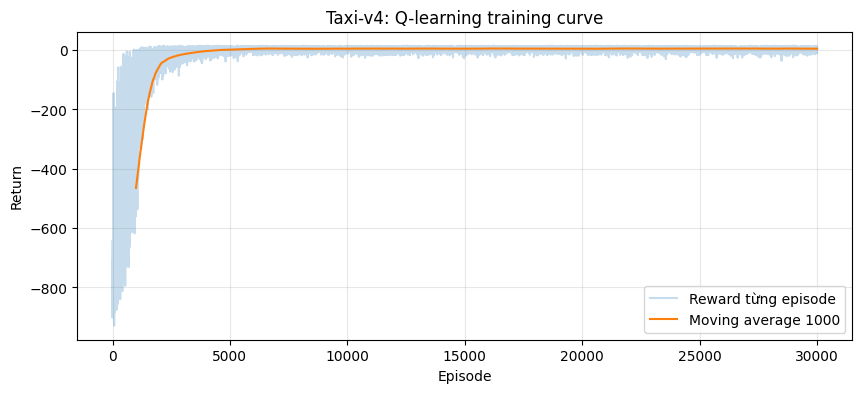

In [7]:
plot_training_curve(
    taxi_train_rewards,
    title="Taxi-v4: Q-learning training curve",
    window=1000
)


### 3.4. Đánh giá policy sau huấn luyện

Khi đánh giá, ta không dùng epsilon-greedy nữa mà dùng policy tham lam:

```python
action = argmax_a Q[state, a]
```

Ta chạy nhiều episode để tính kết quả trung bình.


In [8]:
def evaluate_policy(
    env_id,
    Q,
    episodes=1000,
    max_steps=500,
    seed=2026,
    env_kwargs=None
):
    """
    Đánh giá greedy policy sinh ra từ Q.
    """
    env_kwargs = env_kwargs or {}
    env = gym.make(env_id, **env_kwargs)

    returns = []
    lengths = []

    for ep in range(episodes):
        state, info = env.reset(seed=seed + ep)
        total_reward = 0

        for step in range(max_steps):
            action = greedy_action(Q, state)
            next_state, reward, terminated, truncated, info = env.step(action)

            total_reward += reward
            state = next_state

            if terminated or truncated:
                break

        returns.append(total_reward)
        lengths.append(step + 1)

    env.close()

    print(f"Môi trường: {env_id}")
    print(f"Số episode đánh giá: {episodes}")
    print(f"Return trung bình: {np.mean(returns):.3f}")
    print(f"Return thấp nhất/cao nhất: {np.min(returns):.1f} / {np.max(returns):.1f}")
    print(f"Số bước trung bình: {np.mean(lengths):.2f}")

    return returns, lengths


taxi_eval_returns, taxi_eval_lengths = evaluate_policy(
    "Taxi-v4",
    Q_taxi,
    episodes=1000,
    max_steps=200
)


Môi trường: Taxi-v4
Số episode đánh giá: 1000
Return trung bình: 7.901
Return thấp nhất/cao nhất: 3.0 / 15.0
Số bước trung bình: 13.10


### 3.5. Ghi video một episode Taxi-v4 sau training

Điểm quan trọng: để ghi video bằng `RecordVideo`, môi trường cần được tạo với:

```python
render_mode="rgb_array"
```

Sau đó bọc môi trường bằng:

```python
RecordVideo(...)
```

Hàm dưới đây sẽ:

1. Xóa thư mục video cũ nếu có.
2. Tạo môi trường với `render_mode="rgb_array"`.
3. Chạy một episode bằng greedy policy.
4. Ghi file `.mp4`.
5. Hiển thị video ngay trong notebook.


In [9]:
def record_greedy_episode(
    env_id,
    Q,
    video_folder,
    env_kwargs=None,
    max_steps=500,
    seed=123,
    name_prefix="trained_agent",
    width=480
):
    """
    Ghi và hiển thị một episode dùng greedy policy sau huấn luyện.
    """
    env_kwargs = env_kwargs or {}

    if os.path.exists(video_folder):
        shutil.rmtree(video_folder)
    os.makedirs(video_folder, exist_ok=True)

    env = None

    try:
        env = gym.make(env_id, render_mode="rgb_array", **env_kwargs)
        env = RecordVideo(
            env,
            video_folder=video_folder,
            episode_trigger=lambda episode_id: True,
            name_prefix=name_prefix,
            disable_logger=True
        )

        state, info = env.reset(seed=seed)
        total_reward = 0
        trajectory = []

        for step in range(max_steps):
            action = greedy_action(Q, state)
            next_state, reward, terminated, truncated, info = env.step(action)

            trajectory.append((state, action, reward, next_state))
            total_reward += reward
            state = next_state

            if terminated or truncated:
                break

        env.close()
        env = None

        video_files = sorted(
            glob.glob(os.path.join(video_folder, "*.mp4")),
            key=os.path.getmtime
        )

        print(f"Môi trường: {env_id}")
        print(f"Total reward: {total_reward}")
        print(f"Số bước: {len(trajectory)}")

        if video_files:
            print("File video:", video_files[-1])
            display(Video(video_files[-1], embed=True, width=width))
        else:
            print("Không tìm thấy file .mp4. Hãy kiểm tra cài đặt moviepy/imageio-ffmpeg.")

        return trajectory, video_files

    except Exception as e:
        print("Không ghi được video.")
        print("Lỗi:", repr(e))
        print("\nGợi ý xử lý:")
        print("- Chạy lại cell cài đặt: !pip install \"gymnasium[toy-text]\" moviepy imageio imageio-ffmpeg")
        print("- Khởi động lại runtime/kernel nếu đang dùng Colab.")
        return [], []

    finally:
        if env is not None:
            env.close()


taxi_trajectory, taxi_video_files = record_greedy_episode(
    "Taxi-v4",
    Q_taxi,
    video_folder="videos_taxi",
    max_steps=200,
    seed=2026,
    name_prefix="taxi_after_training",
    width=480
)


/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /content/videos_taxi folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"


Môi trường: Taxi-v4
Total reward: 14
Số bước: 7
File video: videos_taxi/taxi_after_training-episode-0.mp4


## 4. Môi trường Blackjack-v1

### 4.1. Mô tả ngắn

Trong `Blackjack-v1`, agent chơi một ván Blackjack đơn giản. Mục tiêu là thắng nhà cái.

Không gian hành động gồm 2 action:

| Action | Ý nghĩa |
|---:|---|
| 0 | stick: dừng rút bài |
| 1 | hit: rút thêm bài |

Trạng thái là một tuple:

```python
(player_sum, dealer_card, usable_ace)
```

Trong đó:

- `player_sum`: tổng điểm hiện tại của người chơi.
- `dealer_card`: lá bài ngửa của nhà cái.
- `usable_ace`: có quân Át đang dùng như 11 điểm hay không.

Vì state không phải số nguyên từ `0` đến `n-1`, ta sẽ dùng:

```python
defaultdict(lambda: np.zeros(n_actions))
```

thay vì ma trận `numpy` cố định.


In [10]:
BLACKJACK_ACTIONS = {
    0: "stick / dừng",
    1: "hit / rút thêm"
}

env = gym.make("Blackjack-v1")
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)

state, info = env.reset(seed=42)
print("\nState ban đầu:", state)
print("Ý nghĩa state: (player_sum, dealer_card, usable_ace)")

print("\nBảng action:")
for a, meaning in BLACKJACK_ACTIONS.items():
    print(f"{a}: {meaning}")

env.close()


Observation space: Tuple(Discrete(32), Discrete(11), Discrete(2))
Action space: Discrete(2)

State ban đầu: (15, 2, 0)
Ý nghĩa state: (player_sum, dealer_card, usable_ace)

Bảng action:
0: stick / dừng
1: hit / rút thêm


### 4.2. Agent ngẫu nhiên trên Blackjack-v1

Agent ngẫu nhiên thường có tỉ lệ thắng thấp vì hành động `hit` hoặc `stick` cần phụ thuộc mạnh vào tổng điểm hiện tại.


In [11]:
blackjack_random_returns, blackjack_random_lengths = run_random_agent(
    "Blackjack-v1",
    episodes=1000,
    max_steps=100,
    seed=42
)


Môi trường: Blackjack-v1
Số episode: 1000
Return trung bình: -0.40
Số bước trung bình: 1.36


### 4.3. Q-learning cho Blackjack-v1

Với Blackjack, mỗi trạng thái là một bộ ba, ví dụ:

```python
(16, 10, False)
```

Do đó Q-table được lưu bằng dictionary:

```python
Q[state] = np.array([Q(state, stick), Q(state, hit)])
```

Nếu một trạng thái chưa xuất hiện, Q-value ban đầu của nó là vector 0.


In [12]:
def train_blackjack_q_learning(
    episodes=200_000,
    max_steps=100,
    alpha=0.05,
    gamma=1.0,
    epsilon=1.0,
    epsilon_min=0.05,
    epsilon_decay=0.99997,
    seed=42,
    natural=False,
    sab=False
):
    """
    Huấn luyện Q-learning cho Blackjack-v1.

    natural=False, sab=False là thiết lập mặc định thường dùng của Gymnasium.
    """
    env = gym.make("Blackjack-v1", natural=natural, sab=sab)

    n_actions = env.action_space.n
    Q = defaultdict(lambda: np.zeros(n_actions, dtype=np.float64))

    rng = np.random.default_rng(seed)
    rewards = []
    epsilons = []

    for ep in range(episodes):
        state, info = env.reset(seed=seed + ep)
        total_reward = 0

        for step in range(max_steps):
            action = epsilon_greedy_action(Q, state, n_actions, epsilon, rng)
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            best_next_value = 0.0 if done else np.max(Q[next_state])
            td_target = reward + gamma * best_next_value
            td_error = td_target - Q[state][action]
            Q[state][action] += alpha * td_error

            state = next_state
            total_reward += reward

            if done:
                break

        epsilon = max(epsilon_min, epsilon * epsilon_decay)

        rewards.append(total_reward)
        epsilons.append(epsilon)

        if (ep + 1) % 50_000 == 0:
            recent = np.mean(rewards[-5000:])
            print(f"Episode {ep + 1:7d} | return trung bình 5000 episode gần nhất = {recent:.4f} | epsilon = {epsilon:.4f}")

    env.close()
    return Q, rewards, epsilons


Q_blackjack, blackjack_train_rewards, blackjack_epsilons = train_blackjack_q_learning()


Episode   50000 | return trung bình 5000 episode gần nhất = -0.1570 | epsilon = 0.2231
Episode  100000 | return trung bình 5000 episode gần nhất = -0.0716 | epsilon = 0.0500
Episode  150000 | return trung bình 5000 episode gần nhất = -0.0778 | epsilon = 0.0500
Episode  200000 | return trung bình 5000 episode gần nhất = -0.0774 | epsilon = 0.0500


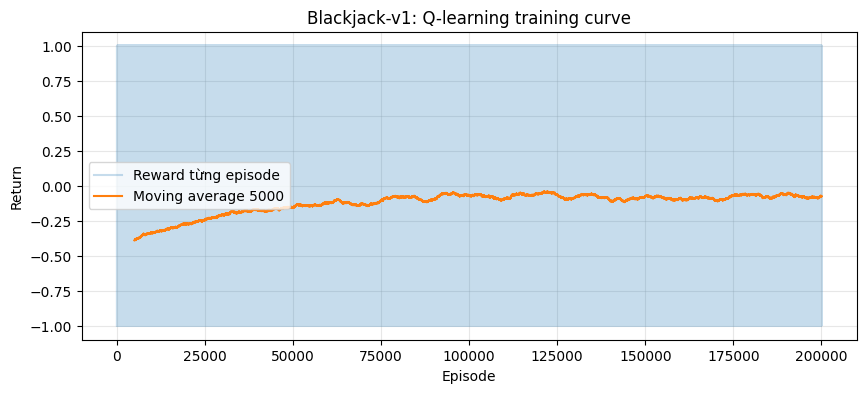

In [13]:
plot_training_curve(
    blackjack_train_rewards,
    title="Blackjack-v1: Q-learning training curve",
    window=5000
)


### 4.4. Đánh giá policy sau huấn luyện trên Blackjack-v1

Trong Blackjack, reward cuối episode thường là:

- `+1`: thắng.
- `0`: hòa.
- `-1`: thua.

Do đó ngoài return trung bình, ta nên báo cáo thêm tỉ lệ thắng, hòa và thua.


In [14]:
def evaluate_blackjack_policy(
    Q,
    episodes=50_000,
    max_steps=100,
    seed=2026,
    natural=False,
    sab=False
):
    """
    Đánh giá greedy policy trên Blackjack-v1.
    """
    env = gym.make("Blackjack-v1", natural=natural, sab=sab)

    returns = []
    lengths = []
    wins = 0
    draws = 0
    losses = 0

    for ep in range(episodes):
        state, info = env.reset(seed=seed + ep)
        total_reward = 0

        for step in range(max_steps):
            action = greedy_action(Q, state)
            next_state, reward, terminated, truncated, info = env.step(action)

            total_reward += reward
            state = next_state

            if terminated or truncated:
                break

        returns.append(total_reward)
        lengths.append(step + 1)

        if total_reward > 0:
            wins += 1
        elif total_reward == 0:
            draws += 1
        else:
            losses += 1

    env.close()

    print("Môi trường: Blackjack-v1")
    print(f"Số episode đánh giá: {episodes}")
    print(f"Return trung bình: {np.mean(returns):.4f}")
    print(f"Tỉ lệ thắng: {wins / episodes:.4f}")
    print(f"Tỉ lệ hòa:   {draws / episodes:.4f}")
    print(f"Tỉ lệ thua:  {losses / episodes:.4f}")
    print(f"Số bước trung bình: {np.mean(lengths):.2f}")

    return {
        "returns": returns,
        "lengths": lengths,
        "win_rate": wins / episodes,
        "draw_rate": draws / episodes,
        "loss_rate": losses / episodes,
    }


blackjack_eval = evaluate_blackjack_policy(
    Q_blackjack,
    episodes=50_000
)


Môi trường: Blackjack-v1
Số episode đánh giá: 50000
Return trung bình: -0.0589
Tỉ lệ thắng: 0.4238
Tỉ lệ hòa:   0.0935
Tỉ lệ thua:  0.4827
Số bước trung bình: 1.56


### 4.5. Xem policy học được trong Blackjack

Ta có thể in policy theo dạng bảng. Ký hiệu:

- `S`: stick.
- `H`: hit.

Bảng bên dưới xét các trạng thái có `player_sum` từ 12 đến 21 và `dealer_card` từ 1 đến 10.


In [15]:
def print_blackjack_policy_table(Q, usable_ace=False):
    """
    In policy Blackjack ở dạng bảng text.
    """
    print("usable_ace =", usable_ace)
    print("H = hit, S = stick")
    print()

    dealer_cards = list(range(1, 11))
    header = "sum\\dealer | " + " ".join(f"{d:>2}" for d in dealer_cards)
    print(header)
    print("-" * len(header))

    for player_sum in range(12, 22):
        row = [f"{player_sum:>10} |"]
        for dealer_card in dealer_cards:
            state = (player_sum, dealer_card, usable_ace)
            action = greedy_action(Q, state)
            symbol = "S" if action == 0 else "H"
            row.append(f"{symbol:>2}")
        print(" ".join(row))


print_blackjack_policy_table(Q_blackjack, usable_ace=False)
print()
print_blackjack_policy_table(Q_blackjack, usable_ace=True)


usable_ace = False
H = hit, S = stick

sum\dealer |  1  2  3  4  5  6  7  8  9 10
------------------------------------------
        12 |  H  H  H  H  H  H  H  H  H  H
        13 |  H  H  S  S  S  H  H  H  H  H
        14 |  H  H  H  S  S  S  H  H  H  H
        15 |  H  S  S  S  S  S  H  S  H  H
        16 |  S  H  S  H  S  S  H  H  H  S
        17 |  S  S  S  S  S  S  S  S  S  S
        18 |  S  S  S  S  S  S  S  S  S  S
        19 |  S  S  S  S  S  S  S  S  S  S
        20 |  S  S  S  S  S  S  S  S  S  S
        21 |  S  S  S  S  S  S  S  S  S  S

usable_ace = True
H = hit, S = stick

sum\dealer |  1  2  3  4  5  6  7  8  9 10
------------------------------------------
        12 |  H  H  H  H  H  H  H  H  H  H
        13 |  H  H  H  H  H  H  H  H  H  H
        14 |  H  H  H  H  H  H  H  H  H  H
        15 |  H  H  H  H  H  H  H  H  H  H
        16 |  H  H  H  H  H  H  H  H  H  H
        17 |  H  H  H  H  H  H  S  H  H  H
        18 |  H  S  H  H  H  S  S  S  H  H
        19 |  S  S 

### 4.6. Ghi video một episode Blackjack-v1 sau training

Ta dùng lại hàm `record_greedy_episode`.

Lưu ý: Blackjack là môi trường dạng trò chơi bài, nên video không giống môi trường lưới như Taxi. Video chủ yếu giúp quan sát trạng thái ván chơi và hành động `hit/stick` của agent.


In [16]:
blackjack_trajectory, blackjack_video_files = record_greedy_episode(
    "Blackjack-v1",
    Q_blackjack,
    video_folder="videos_blackjack",
    env_kwargs={"natural": False, "sab": False},
    max_steps=100,
    seed=2026,
    name_prefix="blackjack_after_training",
    width=480
)


/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /content/videos_blackjack folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Môi trường: Blackjack-v1
Total reward: 0.0
Số bước: 1
File video: videos_blackjack/blackjack_after_training-episode-0.mp4


## 5. So sánh Taxi-v4 và Blackjack-v1

| Tiêu chí | Taxi-v4 | Blackjack-v1 |
|---|---|---|
| Kiểu trạng thái | số nguyên rời rạc | tuple rời rạc |
| Q-table | ma trận `numpy` | `defaultdict` |
| Số action | 6 | 2 |
| Reward | có phạt theo bước, thưởng khi hoàn thành | thắng/hòa/thua |
| Episode | có quá trình di chuyển nhiều bước | thường ngắn |
| Video | trực quan dạng bản đồ lưới | trực quan dạng ván bài |

Điểm chung là cả hai đều có thể dùng **tabular Q-learning** vì số trạng thái hữu hạn và có thể liệt kê được trong thực hành.


## 6. Bài tập thực hành

### Bài 1. Thay đổi số episode huấn luyện

Chạy lại Taxi-v4 với:

```python
episodes = 5_000, 10_000, 30_000
```

Nhận xét:

- Return trung bình thay đổi thế nào?
- Policy có hoàn thành nhiệm vụ ổn định không?
- Video sau training có khác biệt rõ không?


Trả lời:

### Bài 2. Thay đổi `epsilon_decay`

Chạy lại Taxi-v4 hoặc Blackjack-v1 với:

```python
epsilon_decay = 0.999
epsilon_decay = 0.9995
epsilon_decay = 0.99997
```

Nhận xét ảnh hưởng của việc giảm khám phá quá nhanh hoặc quá chậm.


Trả lời:

### Bài 3. So sánh random agent và trained agent

Với mỗi môi trường, lập bảng gồm:

| Môi trường | Agent | Return trung bình | Số bước trung bình / Tỉ lệ thắng |
|---|---|---:|---:|


Trả lời:

### Bài 4. Phân tích policy Blackjack

Quan sát bảng policy Blackjack và trả lời:

- Khi `player_sum` thấp, agent thường `hit` hay `stick`?
- Khi `player_sum` gần 21, agent thường làm gì?
- Sự khác biệt giữa `usable_ace=True` và `usable_ace=False` là gì?


Trả lời:

### Bài 5. Ghi video với các seed khác nhau

Chạy lại:

```python
record_greedy_episode(..., seed=1)
record_greedy_episode(..., seed=2)
record_greedy_episode(..., seed=3)
```

Nhận xét: cùng một policy nhưng episode có giống nhau không? Vì sao?


Trả lời:



## 7. Kết luận

Qua notebook này, sinh viên cần nắm được:

1. `Taxi-v4` dùng Q-table dạng ma trận vì state là số nguyên.
2. `Blackjack-v1` dùng Q-table dạng dictionary vì state là tuple.
3. Q-learning học từ trải nghiệm bằng cập nhật sai số TD.
4. Khi đánh giá policy, cần chạy nhiều episode, không nên chỉ nhìn một episode.
5. Video sau training giúp kiểm tra trực quan agent đã học được hành vi hợp lý hay chưa.
